In [ ]:
pip install opencv-python matplotlib numpy

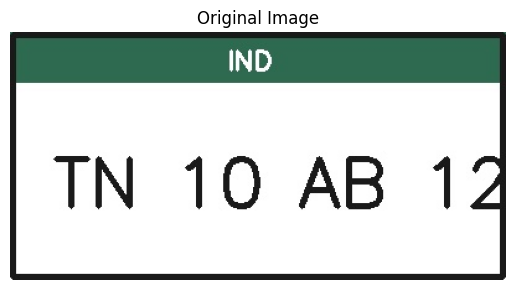

Image Shape: (200, 400, 3)


In [ ]:
import cv2                                     # Import OpenCV library for image processing
import matplotlib.pyplot as plt                # Import Matplotlib for displaying images

# Read the image from the disk into a NumPy array
img = cv2.imread('/number_plate.jpg')           # cv2.imread reads the image in BGR (Blue-Green-Red) format

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check if 'number_plate.jpg' exists and the path is correct.")
else:
    # Convert the BGR image to RGB format since Matplotlib expects RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # This ensures colors look correct when displayed

    # Display the image using Matplotlib
    plt.imshow(img_rgb)                            # Render the RGB image array
    plt.title('Original Image')                    # Add a title to the plot window
    plt.axis('off')                                # Hide the X and Y axes (ticks and borders) for a clean look
    plt.show()                                     # Show the actual window on screen

    # Print the dimensions of the loaded image
    print("Image Shape:", img.shape)               # Outputs (height, width, channels) e.g., (100, 400, 3)

Low-Res Shape: (25, 50, 3)


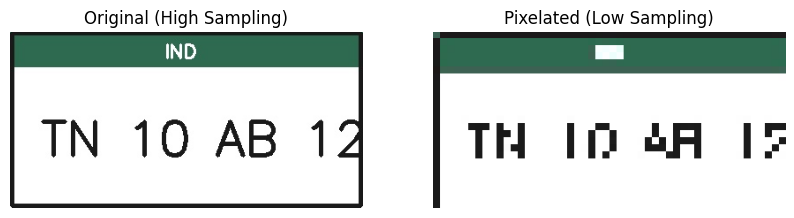

In [ ]:
# Downsample the image to a tiny 50x25 resolution to simulate a very low sampling rate (bad camera sensor)
low_res = cv2.resize(img, (50, 25), interpolation=cv2.INTER_NEAREST) # INTER_NEAREST simply drops pixels without blending
print("Low-Res Shape:", low_res.shape)         # The image is now only 25 pixels high and 50 pixels wide

# Scale the tiny image back up to 400x200 so we can actually see the blocky pixelation effect on screen
pixelated = cv2.resize(low_res, (400, 200), interpolation=cv2.INTER_NEAREST) # Upscale using Nearest Neighbor to keep it blocky

# Create a figure with a specific size (width=10, height=4 inches)
plt.figure(figsize=(10, 4))                                            # Create a visualization window to hold our images

# Create the left subplot (1 row, 2 columns, 1st position)
plt.subplot(1, 2, 1)                                                   # Position this image within a grid layout
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Display the original, high-quality image
plt.title('Original (High Sampling)')                                  # Set a descriptive title for this plot
plt.axis('off')                                                        # Hide axis ticks and coordinates

# Create the right subplot (1 row, 2 columns, 2nd position)
plt.subplot(1, 2, 2)                                                   # Position this image within a grid layout
plt.imshow(cv2.cvtColor(pixelated, cv2.COLOR_BGR2RGB)) # Display the blurred/blocky low-sampling image
plt.title('Pixelated (Low Sampling)')                                  # Set a descriptive title for this plot
plt.axis('off')                                                        # Hide axis ticks and coordinates
plt.show()                                     # Render both subplots to the screen

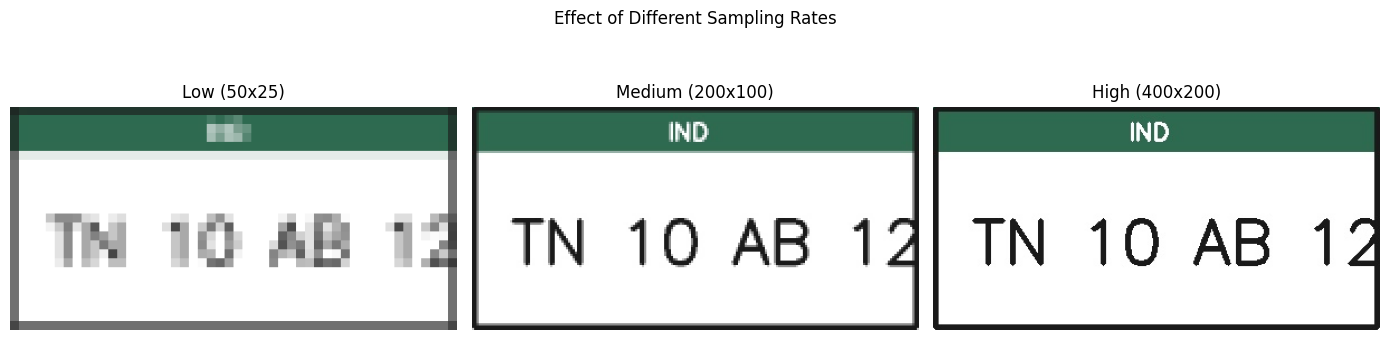

In [ ]:
# Define a list of different resolutions to test (Low, Medium, High)
sizes = [(50, 25), (200, 100), (400, 200)]     # Width x Height tuples
# Labels for our plot titles
labels = ['Low (50x25)', 'Medium (200x100)', 'High (400x200)']         # Define corresponding text labels

plt.figure(figsize=(14, 4))                    # Create a wide figure window

# Loop through each size and label simultaneously
for i, (size, label) in enumerate(zip(sizes, labels)):                 # Iterate through the parameters
    # Step 1: Downsample the original image to the specific 'size' to simulate the sensor resolution
    small = cv2.resize(img, size, interpolation=cv2.INTER_AREA) # INTER_AREA is best for shrinking images

    # Step 2: Upsample it back to 400x200 so we can compare them all at the same physical size
    restored = cv2.resize(small, (400, 200), interpolation=cv2.INTER_NEAREST)  # Upsample image

    plt.subplot(1, 3, i + 1)                   # Create a subplot (1 row, 3 columns, position i+1)
    plt.imshow(cv2.cvtColor(restored, cv2.COLOR_BGR2RGB)) # Show the image
    plt.title(label)                           # Set the title to the current sampling rate label
    plt.axis('off')                            # Hide the axis

plt.suptitle('Effect of Different Sampling Rates') # Add a main title for the whole window
plt.tight_layout()                             # Automatically adjust spacing between plots
plt.show()                                     # Display the final comparison